In [20]:
import numpy as np
import matplotlib.pyplot as plt
# Project Path Setup
from setup_project_path import (
    check_and_add_project_path,
)  # Script to check and add project path
check_and_add_project_path()
from src.AAA.aaa_algorithm import aaa, cleanup
from src.AAA.AAA_kernel import AAARep
from src.kernel_params.kernel_params import KernelParams
from scipy import integrate
from src.utils.common_funcs import initialize_fine_grid, set_time_grid, cont_integral, error_time_integrated
from src.spec_dens.spec_dens import spec_dens_gapless, spec_dens_semi_circle


In [21]:
#function that returns the spectral density
"""def spec_dens(omega):
    omega = np.asarray(omega)  # Ensure omega is a NumPy array
    result = np.zeros_like(omega)  # Initialize result array with the same shape as omega
    
    mask = np.abs(omega) < 1  # Boolean mask for values where abs(omega) < 1
    result[mask] = np.sqrt(1 - omega[mask]**2)  # Apply the formula only where the condition is True
    
    return result"""

Lambda = 10
spec_dens = lambda x: spec_dens_gapless(x, cutoff_lower=-Lambda, cutoff_upper=Lambda) #np.sqrt(1 - x**2) # semi circle spectral density that is nonzero in the interval [-1,1]


#set parameters
params = KernelParams(spec_dens = spec_dens, n = 4263, m = 1000, N_max = 100, delta_t = 0.1, h = 0.005011872336272, beta = 0, phi = 0)



print(params.get_param("m"))

1000


In [22]:
#compute the continuous integral (exact) of the spectral density
time_grid = set_time_grid(params.get_param("N_max"), params.get_param("delta_t"))

cont_integral_particle = cont_integral(time_grid, params.get_param("beta"), np.inf, spec_dens ,0.)
cont_integral_holes = cont_integral(time_grid, -params.get_param("beta"), np.inf, spec_dens ,0.)


cont_integral_concat = np.concatenate((cont_integral_particle, cont_integral_holes), axis=0)


1000
[5.26056881e-10 5.28700029e-10 5.31356458e-10 ... 1.47944428e+02
 1.48687768e+02 1.49434843e+02]
wmax: 150.18567114420256


Text(0, 0.5, 'Spectral Density')

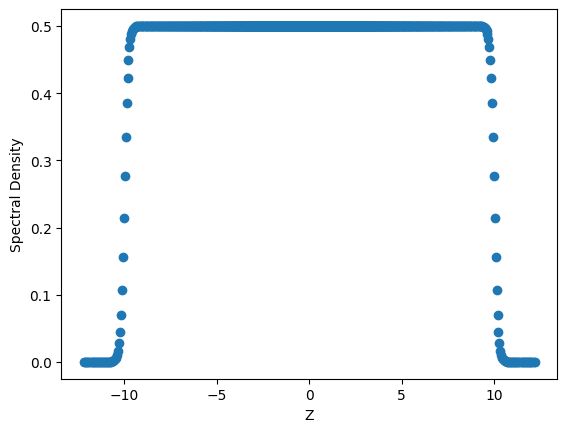

In [23]:
# explicitly get the fine frequency grid
fine_grid, _, _ = initialize_fine_grid(
    params.get_param("m"),
    params.get_param("n"),
    params.get_param("h"),
    freq_parametrization="simple_exp",
)

print(params.get_param("m"))
print(
    np.exp(
        params.get_param("h") * np.arange(-params.get_param("n"), params.get_param("m"))
    )
)
# frequency points in for negativ and positive part on real axis
Z = np.concatenate((-fine_grid[::-1], fine_grid))
#Z = fine_grid

print("wmax:", Z[-1])


# function values, determined by product of spectral density and Fermi Dirac distribution and Jacobian factor h*abs(x)
def func_exact(x):
    f = spec_dens(x) * 1 / (1 + np.exp(-params.get_param("beta") * x))
    f = np.where(np.isnan(f), 0, f)
    return f


F = func_exact(Z)

#plot the spectral density (omit the zeros in the plot)
plt.figure()
vals = spec_dens(Z) * 1 / (1 + np.exp(-params.get_param("beta") * Z))
mask = abs(vals) > 1e-10
plt.scatter(Z[mask], vals[mask])
plt.xlabel("Z")
plt.ylabel("Spectral Density")


In [24]:


# perform AAA algorithm on spectral density multiplied with Fermi-Dirac distribution
# r, errors = aaa(Z = Z, F = F, return_errors=True)
# r = cleanup(r, Z, F)

AAA_kernel = AAARep(**params.params, tol = 1.e-10)
AAA_kernel.remove_Froissart()
r, errors = AAA_kernel.r_particle, AAA_kernel.errors_particle


# Frequency grids
print(
    "\nFine grid (for positive frequencies):\n",
    "first five: ",
    fine_grid[:5],
    "\n last five: ",
    fine_grid[-5:],
)

# print the first 5 nodes
print("\nNodes: \n", r.nodes)
# print the fucntion values
print("\n Func values: \n", r.values)
# print the first 5 poles
print("\nPoles: \n", r.poles()[:5])
# print the first 5 weights
print("\n weights: \n", r.weights[:5])


# compute poles and residues
poles, residues = r.polres()

1 Froissart doublets
1 Froissart doublets

Fine grid (for positive frequencies):
 first five:  [5.26056881e-10 5.28700029e-10 5.31356458e-10 5.34026233e-10
 5.36709423e-10] 
 last five:  [147.20480478 147.94442837 148.68776816 149.43484283 150.18567114]

Nodes: 
 [-150.18567114   -6.32410814   -6.19858804 -148.68776816    0.46682324
    9.39621487    3.50071798   -9.63465309    8.93689498   10.75776143
   -1.28478786  -10.70397979   12.31660116  -10.12983489   10.07919247
  -14.45915756   20.74245909   -9.30250008    9.9287792   -12.13279872
    7.80580477    1.68410577   50.61743283   -9.9287792   -21.69950859
   11.31066641   -8.54273625    6.04518549   14.17217402  -11.03075024
  -17.23157552   10.283294     -7.46153239   15.98363525  -30.66459727
    1.25299195    8.37318109   -4.72884234  132.49905693   -0.42442067
  -13.34494949]

 Func values: 
 [3.72917037e-155 5.00000000e-001 5.00000000e-001 3.72917037e-155
 5.00000000e-001 4.98809501e-001 5.00000000e-001 4.87376406e-001
 4.99

/var/folders/cg/_38xw63s1fg5wbmw91yk0qzr0000gn/T/ipykernel_76451/3019499601.py:6: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "ro" (-> color='r'). The keyword argument will take precedence.
  axs[0].plot(poles.real[poles_mask], poles.imag[poles_mask], 'ro', label = 'Poles', color = 'blue')


Text(0.0001, 0.01, 'nbr. Froisset doublets: 0\n[i.e. abs(residue_k) < 1e-13)]')

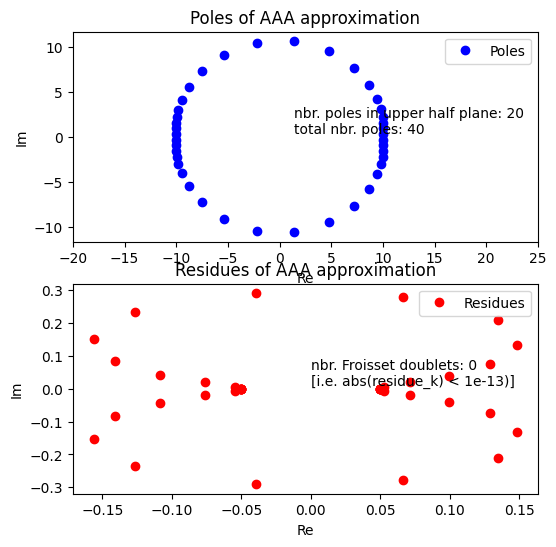

In [25]:
#plot the poles in the complex plane
#subplots in one figure
fig, axs = plt.subplots(2, 1, figsize=(6, 6))
#plot the poles in the complex plane
poles_mask = np.abs(residues) > 0#1.e-13
axs[0].plot(poles.real[poles_mask], poles.imag[poles_mask], 'ro', label = 'Poles', color = 'blue')
axs[0].set_title('Poles of AAA approximation')
axs[0].legend()
axs[0].set_xlabel('Re')
axs[0].set_ylabel('Im')
axs[0].text(1.4,.4, 'nbr. poles in upper half plane: ' + str(len(poles[poles.imag > 0])) + '\n' + 'total nbr. poles: ' + str(len(poles)))
axs[0].set_xlim(-20,25)

#plot the residues in the complex plane
axs[1].plot(residues.real, residues.imag, 'ro', label = 'Residues')
axs[1].set_title('Residues of AAA approximation')
axs[1].legend()
axs[1].set_xlabel('Re')
axs[1].set_ylabel('Im')
#compute number of Froisset doubles:
nbr_doublets = np.sum(np.abs(abs(residues)) < 1e-10)
axs[1].text(.0001,.01, 'nbr. Froisset doublets: ' + str(nbr_doublets) + '\n' + '[i.e. abs(residue_k) < 1e-13)]')



Text(0, 0.5, 'Absolute error: $|f_{exact}(\\omega) - f_{residues}(\\omega)|$')

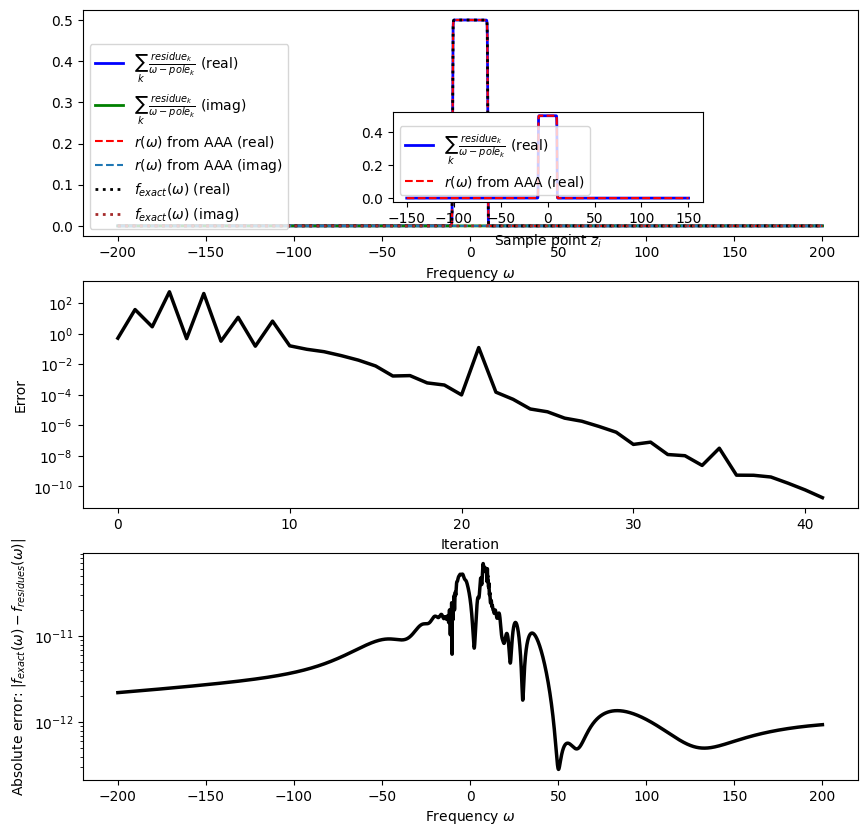

In [26]:
#check that sum over residues divided by poles gives r(z)

#define function as r_check(x) = sum_k residue_k / (x - pole_k)
r_check = lambda x: np.sum([res / (x - pole) for res, pole in zip(residues, poles)])

#range in which we want to plot the function
x_range = np.linspace(-200,200,10000)

#evaluate r_check(x) for each x in x_range
vals_residues = np.array([r_check(x) for x in x_range])
#evaluate func_exact(x) for each x in x_range
vals_exact = np.array([func_exact(x) for x in x_range])
#evaluate r(x) for each x in x_range
vals_rational = r(x_range)


#plot the real and imaginary part of r(x) and the real and imaginary part of r_check(x)
#figure with two subplots
fig, axs = plt.subplots(3, 1, figsize=(10, 10))

axs[0].plot(x_range, vals_residues.real, label = r'$\sum_k \,\frac{residue_k }{ \omega - pole_k}$' + ' (real)' , linewidth = 2, color = "blue")
axs[0].plot(x_range, vals_residues.imag, label = r'$\sum_k \,\frac{residue_k }{ \omega - pole_k}$' + ' (imag)' , linewidth = 2, color = "green")
axs[0].plot(x_range, vals_rational.real, label = r'$r(\omega)$' + ' from AAA (real)' , linestyle = '--', color = "red")
axs[0].plot(x_range, vals_rational.imag, label = r'$r(\omega)$' + ' from AAA (imag)' , linestyle = '--')
axs[0].plot(x_range, vals_exact.real, label = r'$f_{exact}(\omega)$' + ' (real)' , linestyle = 'dotted', linewidth = 2, color = "black")
axs[0].plot(x_range, vals_exact.imag, label = r'$f_{exact}(\omega)$' + ' (imag)' , linestyle = 'dotted', linewidth = 2, color = "brown")
axs[0].legend(loc = "lower left")
axs[0].set_xlabel('Frequency ' + r'$\omega$')

#make inset plot
axins = axs[0].inset_axes([0.4, 0.15, 0.4, 0.4])
axins.plot(Z, np.array([r_check(z) for z in Z]).real, label = r'$\sum_k \,\frac{residue_k }{ \omega - pole_k}$' + ' (real)' , linewidth = 2, color = "blue")
axins.plot(Z, r(Z).real, label = r'$r(\omega)$' + ' from AAA (real)' , linestyle = '--', color = "red")
axins.legend()
axins.set_xlabel('Sample point ' + r'$z_i$')


#plot the error as function of iteration
axs[1].plot(errors, label = 'Error', linewidth = 2.5, color = 'black')
axs[1].set_yscale('log')
axs[1].set_xlabel('Iteration')
axs[1].set_ylabel('Error')



#plot the absolute error between the exact function and the rational approximation
axs[2].plot(x_range, np.abs(vals_exact - vals_residues), label = 'Absolute error', linewidth = 2.5, color = 'black')
axs[2].set_yscale('log')
axs[2].set_xlabel('Frequency ' + r'$\omega$')
axs[2].set_ylabel('Absolute error: ' + r'$|f_{exact}(\omega) - f_{residues}(\omega)|$')


In [27]:
G_learned = AAA_kernel.propagator_AAA(time_grid)
error_plain = abs(G_learned - cont_integral_concat)
#compute the error between the continuous integral and the AAA approximation
error = error_time_integrated(cont_integral_concat, G_learned, params.params["delta_t"])
print("error", error)

error 4.1743241142109215e-11


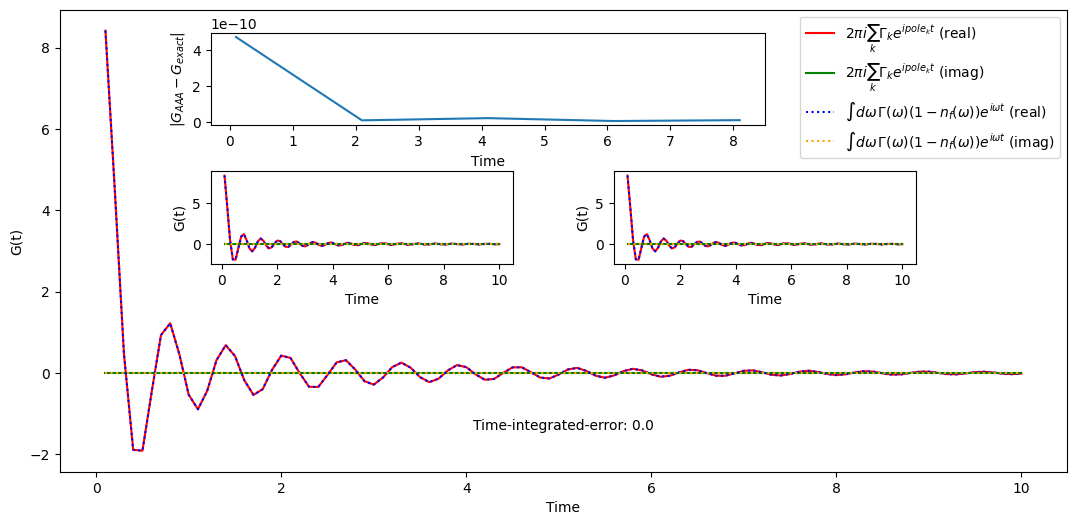

In [28]:
#compute the Green's function as contiuous integral

#check that "learned propagator is close to the reference propagator"
residues_upper = residues[poles.imag > 0]
poles_upper = poles[poles.imag > 0]



#plot the learned propagator and the reference propagator
fig, ax = plt.subplots(figsize=(13, 6))
#plt.plot(time_grid, AAA_GF[:,0].real, label=r'$\int d\omega \, r(\omega) e^{i\omega t} $' + ' (real)', color = 'purple', linestyle = '-', alpha = 0.8)
#plt.plot(time_grid, AAA_GF[:,0].imag, label=r'$\int d\omega \, r(\omega) e^{i\omega t} $' + ' (imag)', linestyle = '-', alpha = 0.8)
ax.plot(time_grid, G_learned[:len(time_grid)].real, label=r'$2\pi i \sum_k \Gamma_k e^{i pole_k t} $' + ' (real)', color = 'red', linestyle = '-')
ax.plot(time_grid, G_learned[:len(time_grid)].imag, label=r'$2\pi i \sum_k \Gamma_k e^{i pole_k t} $' + ' (imag)', color = 'green', linestyle = '-')
ax.plot(time_grid, cont_integral_particle.real, label=r'$\int d\omega \, \Gamma(\omega) (1-n_f(\omega)) e^{i\omega t} $' + ' (real)', color = 'blue', linestyle = 'dotted')
ax.plot(time_grid, cont_integral_particle.imag, label=r'$\int d\omega \, \Gamma(\omega) (1-n_f(\omega)) e^{i\omega t} $' + ' (imag)', color = 'orange', linestyle = 'dotted')
       
ax.legend()
ax.set_xlabel('Time')
ax.set_ylabel('G(t)')


#add inset for a given x-range
axins = ax.inset_axes([0.55, 0.45, 0.3, 0.2])
axins.plot(time_grid[-200:], G_learned[:len(time_grid)].real[-200:], label=r'$2\pi i \sum_k \Gamma_k e^{i pole_k t} $' + ' (real)', color = 'red', linestyle = '-')
axins.plot(time_grid[-200:], G_learned[:len(time_grid)].imag[-200:], label=r'$2\pi i \sum_k \Gamma_k e^{i pole_k t} $' + ' (imag)', color = 'green', linestyle = '-')
axins.plot(time_grid[-200:], cont_integral_particle.real[-200:], label=r'$\int d\omega \, \Gamma(\omega) (1-n_f(\omega)) e^{i\omega t} $' + ' (real)', color = 'blue', linestyle = 'dotted')
axins.plot(time_grid[-200:], cont_integral_particle.imag[-200:], label=r'$\int d\omega \, \Gamma(\omega) (1-n_f(\omega)) e^{i\omega t} $' + ' (imag)', color = 'orange', linestyle = 'dotted')
axins.set_xlabel('Time')
axins.set_ylabel('G(t)')

axins = ax.inset_axes([0.15, 0.45, 0.3, 0.2])
axins.plot(time_grid[:200], G_learned[:len(time_grid)].real[:200], label=r'$2\pi i \sum_k \Gamma_k e^{i pole_k t} $' + ' (real)', color = 'red', linestyle = '-')
axins.plot(time_grid[:200], G_learned[:len(time_grid)].imag[:200], label=r'$2\pi i \sum_k \Gamma_k e^{i pole_k t} $' + ' (imag)', color = 'green', linestyle = '-')
axins.plot(time_grid[:200], cont_integral_particle.real[:200], label=r'$\int d\omega \, \Gamma(\omega) (1-n_f(\omega)) e^{i\omega t} $' + ' (real)', color = 'blue', linestyle = 'dotted')
axins.plot(time_grid[:200], cont_integral_particle.imag[:200], label=r'$\int d\omega \, \Gamma(\omega) (1-n_f(\omega)) e^{i\omega t} $' + ' (imag)', color = 'orange', linestyle = 'dotted')
axins.set_xlabel('Time')
axins.set_ylabel('G(t)')

axins = ax.inset_axes([0.15, 0.75, 0.55, 0.2])
axins.plot(time_grid[::20], error_plain[:len(time_grid):20], linestyle = '-')
axins.set_xlabel('Time')
axins.set_ylabel(r'$|G_{AAA} - G_{exact}|$')

ax.text(0.5, 0.1, 'Time-integrated-error: ' + str(np.round(error,4)), horizontalalignment='center', verticalalignment='center', transform=ax.transAxes)


plt.show()
